In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import datetime

In [2]:
colnames = ["time_interval", "id_1", "id_2", "class_id_1", "class_id_2"]

df_2012 = pd.read_csv(
    "/home/scc/miranda.barros-everett/NetworkRugs/Miranda/thiers_2012.csv",
    sep="\t",
    header=None,
    names=colnames
)

# Convert to datetime (UTC)
df_2012["datetime_utc"] = pd.to_datetime(df_2012["time_interval"], unit="s", utc=True)

print("2012 interactions:")
display(df_2012)




2012 interactions:


,time_interval,id_1,id_2,class_id_1,class_id_2,datetime_utc
0,1353303380,1170,1644,MP*1,MP*1,2012-11-19 05:36:20+00:00
1,1353303400,1170,1613,MP*1,MP*1,2012-11-19 05:36:40+00:00
2,1353303640,1170,1644,MP*1,MP*1,2012-11-19 05:40:40+00:00
3,1353303760,1181,1651,MP*1,MP*1,2012-11-19 05:42:40+00:00
4,1353303840,1108,1190,MP*1,MP*1,2012-11-19 05:44:00+00:00
...,...,...,...,...,...,...
45042,1354032580,880,887,PC*,PC*,2012-11-27 16:09:40+00:00
45043,1354032580,854,869,PSI*,PSI*,2012-11-27 16:09:40+00:00
45044,1354032600,880,887,PC*,PC*,2012-11-27 16:10:00+00:00
45045,1354032760,620,669,MP*2,MP*2,2012-11-27 16:12:40+00:00


In [3]:
G_2012 = nx.from_pandas_edgelist(df_2012, "id_1", "id_2")

print()
print("2012 network data:")
print(f"Number of nodes: {G_2012.number_of_nodes()}")
print(f"Number of edges: {G_2012.number_of_edges()}")

num_unique_intervals = df_2012["time_interval"].nunique()
print(f"Number of timestamps: {num_unique_intervals}")



2012 network data:
Number of nodes: 180
Number of edges: 2220
Number of timestamps: 11273


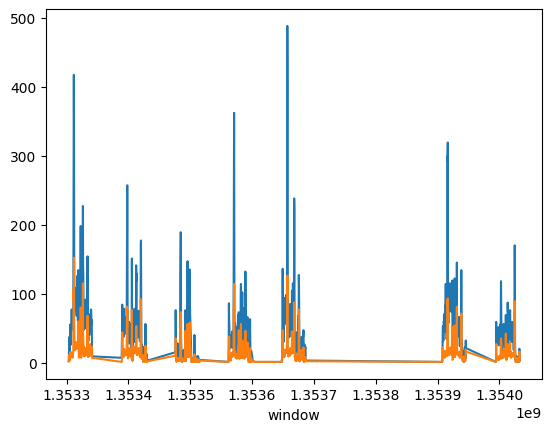

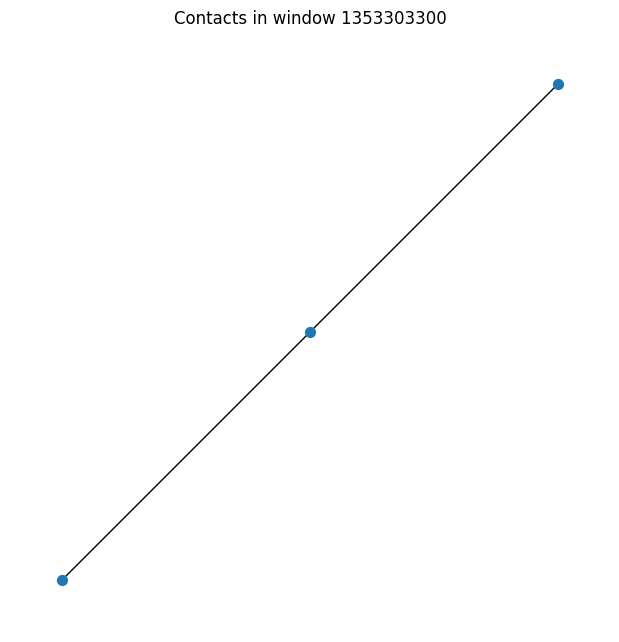

In [4]:
# Creating window column
window = 300  # 5 minutes in seconds
df_2012["window"] = (df_2012["time_interval"] // window) * window

# Interactions per window overview
interactions_per_window = (
    df_2012
    .groupby("window")
    .size()
)

interactions_per_window.plot()

# How many unique pairs per window? Since we are NOT USING WEIGHTS YET, have to count each interaction within the window only once
df_2012["u"] = df_2012[["id_1", "id_2"]].min(axis=1)
df_2012["v"] = df_2012[["id_1", "id_2"]].max(axis=1)

unique_pairs_per_window = (
    df_2012
    .drop_duplicates(subset=["window", "u", "v"])
    .groupby("window")
    .size()
)
unique_pairs_per_window.plot()

# Visualizing a single window network
one_window = df_2012["window"].iloc[0]
df_w = df_2012[df_2012["window"] == one_window]
# Deduplicating edges
edges = df_w.drop_duplicates(subset=["u", "v"])

G = nx.from_pandas_edgelist(edges, "u", "v")

plt.figure(figsize=(6, 6))
nx.draw(G, node_size=50, with_labels=False)
plt.title(f"Contacts in window {one_window}")
plt.show()





In [5]:
# ensuring global node setting (reference roster of students)
nodes = pd.unique(df_2012[["id_1", "id_2"]].values.ravel())
print(f"Total unique students: {len(nodes)}")


Total unique students: 180


In [6]:
# this filters out windows without any interactions, so they don't show up in network rugs
# building snapshot graphs per window
graphs = {}

for w, df_w in df_2012.groupby("window"):
    G = nx.Graph()
    
    # add all nodes (stable across time)
    G.add_nodes_from(nodes)
    
    # deduplicate edges within the window
    edges = df_w.drop_duplicates(subset=["u", "v"])
    G.add_edges_from(edges[["u", "v"]].itertuples(index=False)) # Prevents multiple identical (u,v) edges from being added, adds edges to each graph
    
    graphs[w] = G # storing graph for this 



In [8]:

from ba_utils.visualization import draw_rug_from_graphs
from ba_utils.orderings import get_priority_bfs_ordering
prio_bfs_ordering = get_priority_bfs_ordering(graphs)

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Global stats: ((1, 1), (0, 15), (0, 7))
Priority BFS Ordering:
num_artists 1


Rug plot reveals that in this window, only one node is reachable via priority expansion, because the start node is isolated. The only solution I can think of without changing the algorithm is choosing the start node, and to choose one that appears in interactions.

### Testing Frederikes wrapper function draw_networkrug (wrapper for draw_rug_from_graphs)

num_artists 180


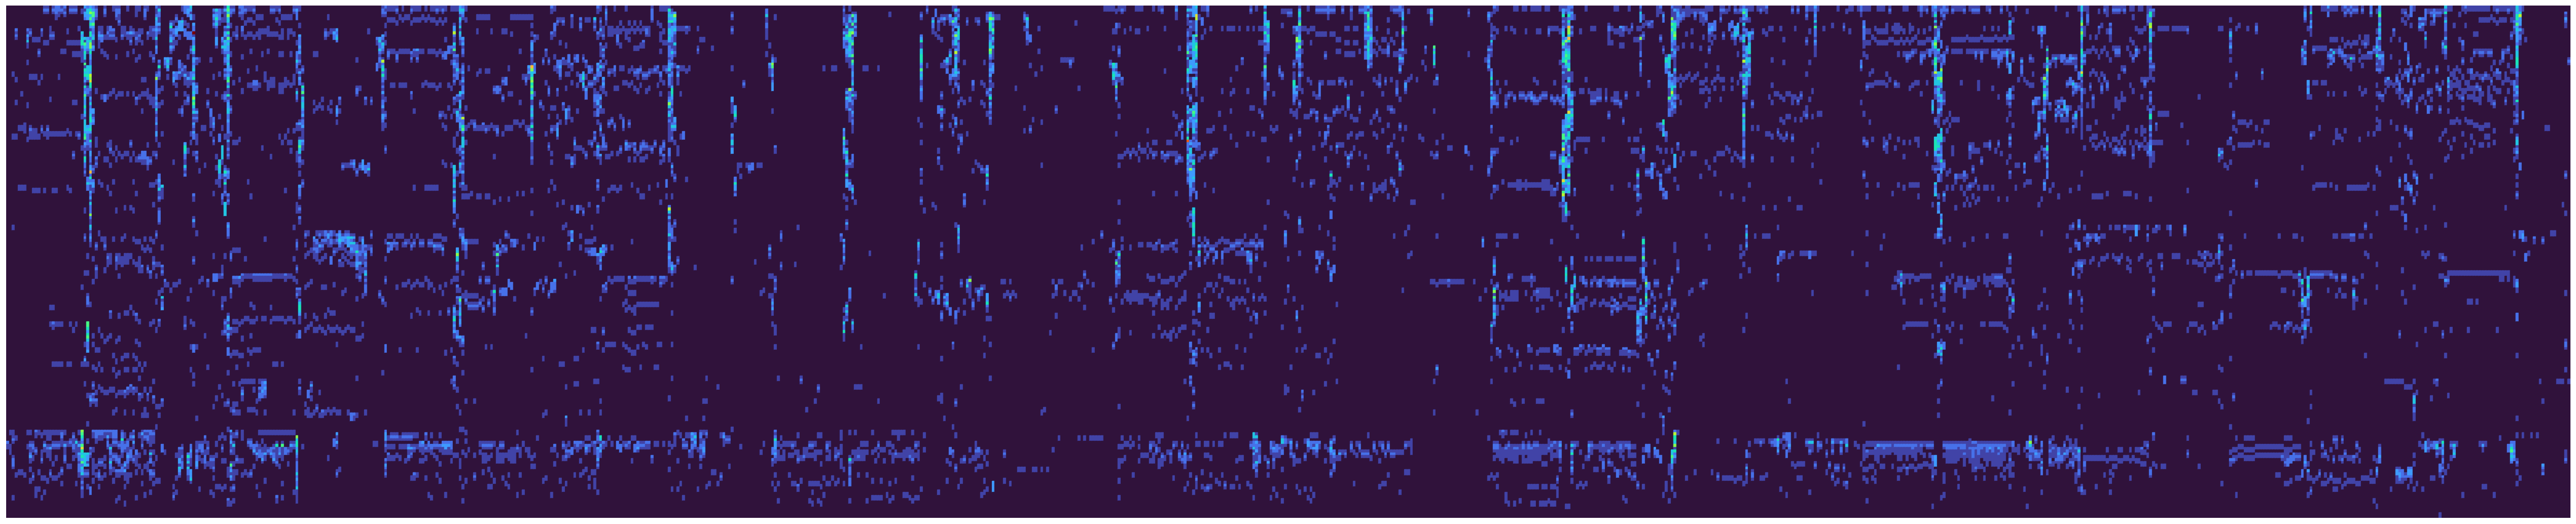

In [11]:
from ba_utils.network_rugs import draw_networkrug

draw_networkrug(
    graphs=graphs,
    order="bfs",
    color_encoding="degree",
    pixel_size=6
)
